# Example of dataset helpers

In [12]:
!uv sync --group=dev

Resolved 154 packages in 37ms
Audited 149 packages in 28ms


In [2]:
import hierarchical_binary_quantization.misc.dataset_helpers as dh
import hierarchical_binary_quantization.misc.image_helpers as ih

from torchvision import transforms
import os
import io
from torch.utils.data import Dataset
from PIL import Image

In [3]:
def recreate_database(name,src_path,w=240,h=320):
    output_db = f"data/dbs/{name}_{w}_{h}.sqlite3"
    if os.path.exists(output_db):
        print(f"{output_db} already exists")
        return
    dh.make_w_h_dataset(src_path,output_db,w=w,h=h)

recreate_database("fantasy","data/fantasy",w=256,h=256)
recreate_database("pokemon","data/pokemon_archive",w=256,h=256)


data/dbs/fantasy_256_256.sqlite3 already exists
data/dbs/pokemon_256_256.sqlite3 already exists


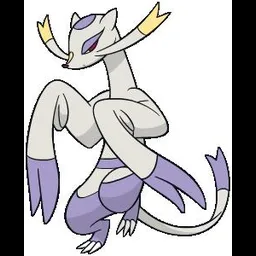

In [ ]:
transform = transforms.Compose([
    dh.PadToRectangle(256,256),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])
bds = dh.BlobDataset("data/dbs/pokemon_256_256.sqlite3","r")
imgds = dh.ImageDataset(bds, transform)
next(iter(imgds))
imgds[10]
ih.tensor_to_pil(imgds[10])

In [11]:
import torch

from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import v2
from torchvision.transforms.v2 import functional as TF
class AugmentedHRLRDataset(Dataset):
    def __init__(self, root, HR, LR, aug: dh.SimpleAugmentConfig | None = None):
        self.HR = HR
        self.LR = LR
        self.aug = aug or dh.SimpleAugmentConfig()

        self.base = datasets.ImageFolder(
            root=root,
            transform=v2.Compose([
                v2.ToImage(),
                v2.ToDtype(torch.float32, scale=True),
                v2.Lambda(dh.to_minus_one_one),
            ])
        )

        self.color = v2.ColorJitter(
            brightness=0.1,
            hue=0.5
        )

    def __len__(self):
        return len(self.base)

    def _resize_if_needed(self, img, size):
        if img.shape[1] == size:
            return img
        out =  F.interpolate(
            img.unsqueeze(0),
            size=(size, size),
            mode="bicubic",
            align_corners=False,
            antialias=True
        ).squeeze(0)
        return torch.clamp(out, -1.0, 1.0)

    def __getitem__(self, idx):
        orig, _ = self.base[idx]

        hr = orig.clone()
        #print(f"in AugmentedHRLRDataset a {hr.shape}, {orig.shape}")

        # Flip
        if self.aug.hflip and torch.rand(1) < 0.5:
            hr = torch.flip(hr, dims=[2])
        #print(f"in AugmentedHRLRDataset b {hr.shape}, {orig.shape}")

        # Crop
        if self.aug.crop:
            hr = dh.top_biased_square_crop(hr, self.aug)
            #print(f"in AugmentedHRLRDataset c {hr.shape}, {orig.shape}")

        # Resize to HR
        hr = self._resize_if_needed(hr, self.HR)
        #print(f"in AugmentedHRLRDataset d {hr.shape}, {orig.shape}")

        # Color jitter (expects [0,1])
        if self.aug.color_jitter:
            hr = dh.skin_preserving_color_jitter(hr, self.color)

        # LR derived from HR
        lr = self._resize_if_needed(hr.clone(), self.LR)
        #print(f"in AugmentedHRLRDataset {hr.shape}, {lr.shape}, {orig.shape}")

        return hr, lr, orig
